# 04 · Conclusiones y evaluación final

**Prerequisito:** haber ejecutado `03_modeling.ipynb` para generar los modelos.

Este es el **único notebook que mira el conjunto de test**.

Hasta ahora hemos comparado los modelos con el conjunto de *validación*.
Aquí hacemos la evaluación definitiva: aplicamos los tres modelos al conjunto de test
(datos que ningún modelo ha visto nunca) y decidimos cuál es el mejor.

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

ROOT = Path('..').resolve()
sys.path.append(str(ROOT))
from src.utils import metricas_test, plot_resultados, plot_comparativa, cargar_modelo

SPLITS_DIR  = ROOT / 'data' / 'splits'
MODELS_DIR  = ROOT / 'models'
FIGURES_DIR = ROOT / 'reports' / 'figures'

print('Librerías cargadas.')

Librerías cargadas.


## 1 · Carga de datos y modelos

In [2]:
X_test = pd.read_csv(SPLITS_DIR / 'X_test.csv', index_col=0)
y_test = pd.read_csv(SPLITS_DIR / 'y_test.csv', index_col=0).squeeze()

best_lasso = cargar_modelo(MODELS_DIR / 'lasso.joblib')
best_ridge = cargar_modelo(MODELS_DIR / 'ridge.joblib')
best_en    = cargar_modelo(MODELS_DIR / 'elasticnet.joblib')
best_rf    = cargar_modelo(MODELS_DIR / 'random_forest.joblib')
best_gb    = cargar_modelo(MODELS_DIR / 'gradient_boosting.joblib')

print(f'\nTest: {X_test.shape[0]} filas')

Modelo cargado desde C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\lasso.joblib
Modelo cargado desde C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\ridge.joblib
Modelo cargado desde C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\elasticnet.joblib
Modelo cargado desde C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\random_forest.joblib
Modelo cargado desde C:\Users\rammu\Documents\projects\Machine_learning\Entrega final\machine_learning_final\models\gradient_boosting.joblib

Test: 1980 filas


## 2 · Evaluación final sobre test

In [3]:
modelos = {
    'Lasso':             best_lasso,
    'Ridge':             best_ridge,
    'ElasticNet':        best_en,
    'Random Forest':     best_rf,
    'Gradient Boosting': best_gb,
}

# expm1 deshace el log1p aplicado en 02_data_preparation → métricas en euros
resultados = pd.DataFrame([
    metricas_test(nombre, np.expm1(y_test), np.expm1(modelo.predict(X_test)))
    for nombre, modelo in modelos.items()
]).set_index('Modelo')

resultados

,RMSE (€),MAE (€),R²
Modelo,,,
Lasso,44.40,18.99,0.4866
Ridge,44.06,18.98,0.4944
ElasticNet,44.51,19.01,0.4839
Random Forest,45.83,19.19,0.4530
Gradient Boosting,37.43,16.80,0.6351


## 3 · Comparación gráfica

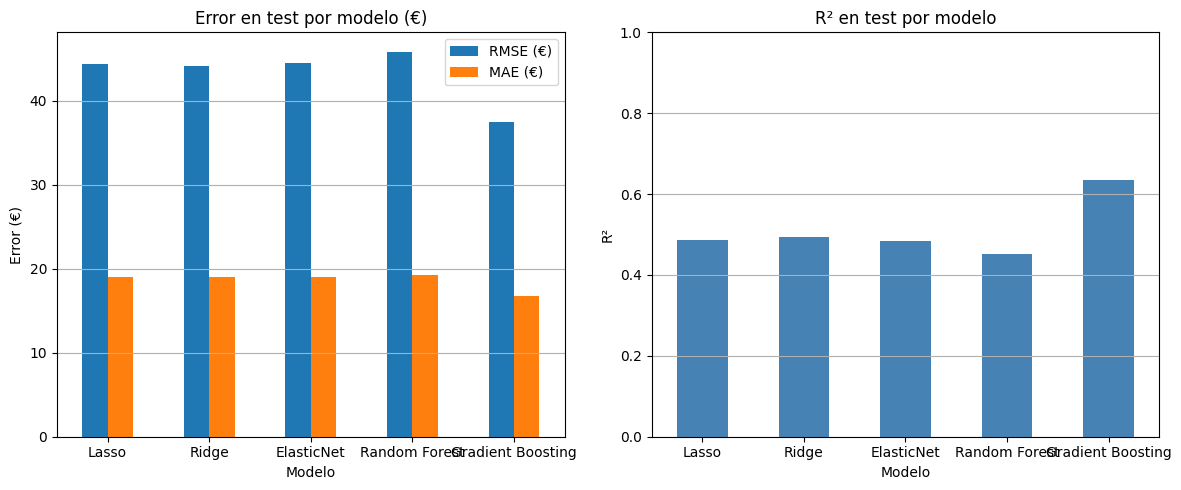

In [4]:
plot_comparativa(resultados, figures_dir=FIGURES_DIR)

## 4 · Análisis del mejor modelo

In [5]:
mejor_nombre = resultados['RMSE (€)'].idxmin()
mejor_modelo = modelos[mejor_nombre]
pred_mejor   = np.expm1(mejor_modelo.predict(X_test))
y_test_euros = np.expm1(y_test)

print(f'Mejor modelo: {mejor_nombre}')
print(f'  RMSE: {resultados.loc[mejor_nombre, "RMSE (€)"]} €')
print(f'  MAE:  {resultados.loc[mejor_nombre, "MAE (€)"]} €')
print(f'  R²:   {resultados.loc[mejor_nombre, "R²"]}')

Mejor modelo: Gradient Boosting
  RMSE: 37.43 €
  MAE:  16.8 €
  R²:   0.6351


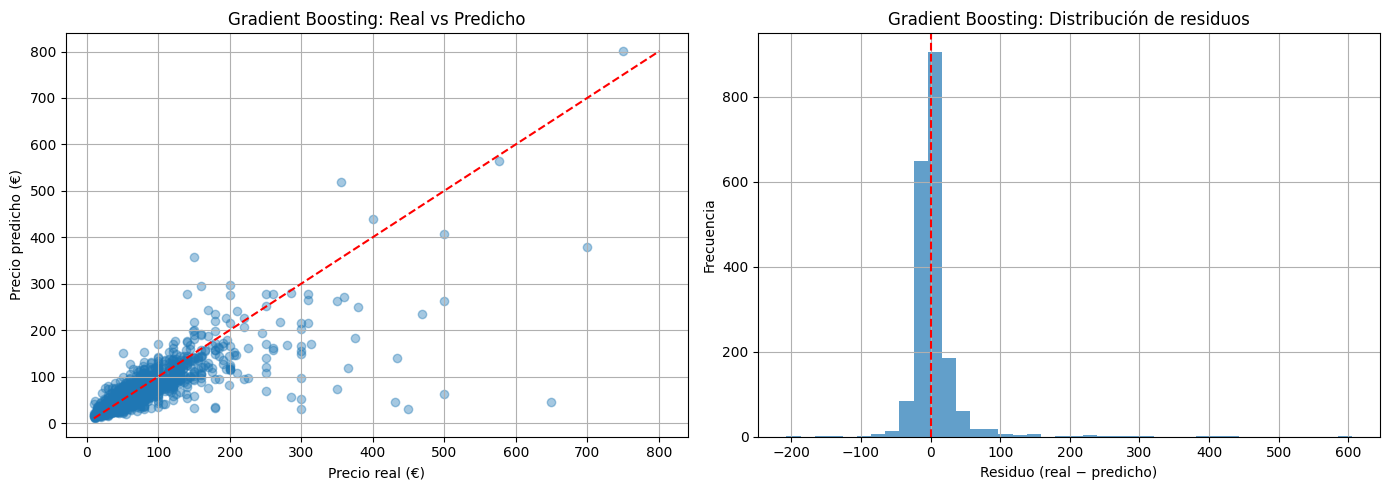

In [6]:
plot_resultados(mejor_nombre, y_test_euros, pred_mejor, figures_dir=FIGURES_DIR)

## 5 · Conclusiones

*(Edita esta celda con tus conclusiones una vez ejecutado el notebook)*

**Modelo ganador:** …

**Interpretación del error:** un RMSE de X € significa que, de media, el modelo se equivoca en ±X € al predecir el precio de un alojamiento en Madrid.

**Observaciones sobre los residuos:**
- ¿El modelo tiende a subestimar precios altos?
- ¿Hay sesgo sistemático (la distribución de residuos no está centrada en 0)?

**Variables más influyentes:**
- Número de habitaciones y capacidad de personas
- Tipo de habitación (habitación privada vs. apartamento entero)
- …

**Posibles mejoras futuras:**
- Transformación logarítmica del precio para reducir el efecto de outliers
- Probar Gradient Boosting o XGBoost
- Incluir variables de texto (descripción del alojamiento) mediante NLP